In [22]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image

# Load the trained model
print("Loading model...")
model = load_model('C:/Users/fares/Downloads/projet/TP5/expoted_Models/best_mnist_modelVersionLight.h5')
print("Model loaded successfully!")


# Load image
img = Image.open("C:\\Users\\fares\\Downloads\\projet\\TP5\\donnée_pour_test\\4.png").convert('L')  # Convert to grayscale

# Resize to 28x28
img = img.resize((28, 28))

# Convert to array and normalize
img_array = np.array(img)

# Invert if needed (MNIST expects white digit on black background)
# Check if background is mostly white
if np.mean(img_array) > 127:
    img_array = 255 - img_array  # Invert

# Normalize to [0, 1]
img_array = img_array.astype('float32') / 255.0

# Reshape for model input (1, 28, 28, 1)
img_array = img_array.reshape(1, 28, 28, 1)



Loading model...
Model loaded successfully!


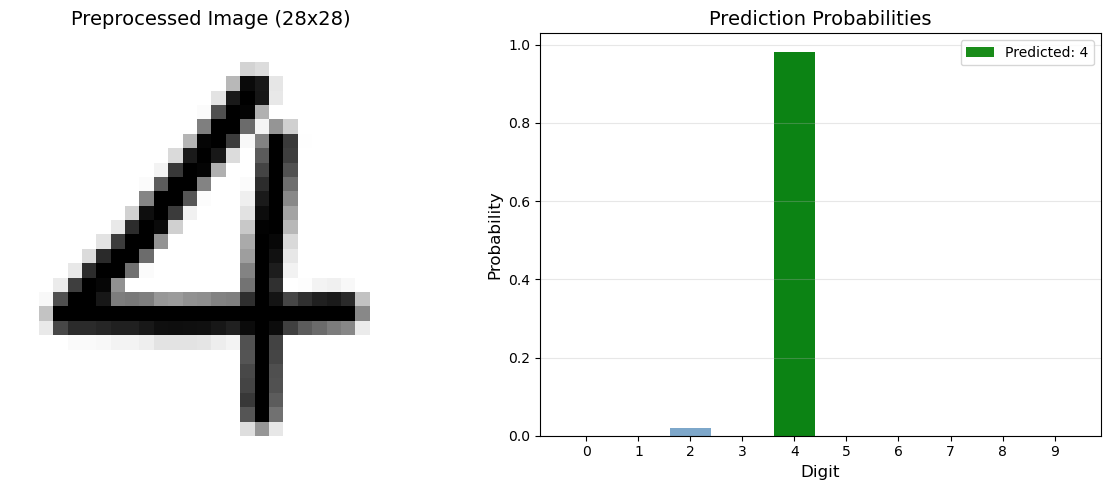


CLASSIFICATION RESULTS
Predicted Digit: 4
Confidence: 98.03%

All probabilities:
  Digit 0:  0.00% 
  Digit 1:  0.00% 
  Digit 2:  1.97% 
  Digit 3:  0.00% 
  Digit 4: 98.03% █████████████████████████████████████████████████
  Digit 5:  0.00% 
  Digit 6:  0.00% 
  Digit 7:  0.00% 
  Digit 8:  0.00% 
  Digit 9:  0.00% 


In [23]:

"""
Classify an uploaded image
"""


# Make prediction
predictions = model.predict(img_array, verbose=0)
predicted_digit = np.argmax(predictions[0])
confidence = predictions[0][predicted_digit] * 100

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Show original/preprocessed image
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Preprocessed Image (28x28)', fontsize=14)
axes[0].axis('off')

# Show prediction probabilities
axes[1].bar(range(10), predictions[0], color='steelblue', alpha=0.7)
axes[1].bar(predicted_digit, predictions[0][predicted_digit], 
            color='green', alpha=0.9, label=f'Predicted: {predicted_digit}')
axes[1].set_xlabel('Digit', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title('Prediction Probabilities', fontsize=14)
axes[1].set_xticks(range(10))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('classification_result.png', dpi=150, bbox_inches='tight')
plt.show()

# Print results
print("\n" + "="*50)
print("CLASSIFICATION RESULTS")
print("="*50)
print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")
print("\nAll probabilities:")
for digit in range(10):
    prob = predictions[0][digit] * 100
    bar = '█' * int(prob / 2)
    print(f"  Digit {digit}: {prob:5.2f}% {bar}")
print("="*50)